In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import average_precision_score

sys.path.append(str(Path.cwd().parent))

from src.config import (  # noqa: E402
    MIN_RECALL, MODELS_DIR, RANDOM_STATE, REVIEW_COST)
from src.data_loader import load_data  # noqa: E402
from src.evaluate import (  # noqa: E402
    compute_metrics, plot_confusion_matrices, plot_pr_curves)
from src.explain import (  # noqa: E402
    build_explainer, explain_transaction, plot_global_importance,
    plot_waterfall, sample_for_shap)
from src.imbalance import compute_scale_pos_weight  # noqa: E402
from src.inference import (  # noqa: E402
    load_artifacts, save_artifacts, score_and_explain)
from src.preprocessing import remove_duplicates  # noqa: E402
from src.split import stratified_split, summarize_split  # noqa: E402
from src.threshold import (  # noqa: E402
    add_cost, average_fraud_amount, cost_at_threshold,
    plot_threshold_curves, select_cost_threshold,
    select_recall_threshold, threshold_table)
from src.train_advanced import (  # noqa: E402
    anomaly_scores, anomaly_threshold, compare_imbalance_strategies,
    fit_final_model, fit_isolation_forest)
from src.train_baseline import build_pipeline  # noqa: E402
from src.tuning import (  # noqa: E402
    cv_oof_predictions, load_record, make_folds, tune_model)

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

df, _ = remove_duplicates(load_data(verbose=False))
X_train, X_test, y_train, y_test = stratified_split(df)
summarize_split(y_train, y_test, "Stratified 80/20 (same as Stage 2)")

c:\Users\gopu8\OneDrive\Desktop\ML_PROJ\credit-card-fraud-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removed 1,081 duplicate rows (0.380%); 283,726 rows remain.

Stratified 80/20 (same as Stage 2)
       n_rows  n_fraud  n_legit  fraud_pct
train  226980      378   226602     0.1665
test    56746       95    56651     0.1674


,n_rows,n_fraud,n_legit,fraud_pct
train,226980,378,226602,0.166534
test,56746,95,56651,0.167413


1. The number to beat
Copy these from your Stage 2 table (best row by PR-AUC).

In [2]:
BASELINE_LABEL = "rf + none"
BASELINE_CV_PR_AUC = 0.839

2. scale_pos_weight vs SMOTE (boosted trees)

Fixed 300 trees, default parameters, 5-fold CV. SMOTE runs inside each training fold only. We compare strategies before tuning to decide what to tune. Runtime: about 5-12 minutes.

In [3]:
imb_results, imb_oof = compare_imbalance_strategies(X_train, y_train)
display(imb_results.sort_values("pr_auc", ascending=False).round(3))

xgb + none             PR-AUC=0.847 recall=0.804 (16s)
xgb + class_weight     PR-AUC=0.847 recall=0.828 (19s)


c:\Users\gopu8\OneDrive\Desktop\ML_PROJ\credit-card-fraud-detection\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\gopu8\OneDrive\Desktop\ML_PROJ\credit-card-fraud-detection\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\gopu8\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\gopu8\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args,

xgb + smote            PR-AUC=0.844 recall=0.833 (38s)
lgbm + none            PR-AUC=0.152 recall=0.241 (16s)
lgbm + class_weight    PR-AUC=0.019 recall=0.822 (13s)
lgbm + smote           PR-AUC=0.706 recall=0.807 (32s)


,precision,recall,f1,pr_auc,roc_auc,pr_auc_std,cv_time_s
model + strategy,,,,,,,
xgb + class_weight,0.907,0.828,0.864,0.847,0.982,0.031,19.115
xgb + none,0.946,0.804,0.868,0.847,0.982,0.027,15.685
xgb + smote,0.808,0.833,0.820,0.844,0.979,0.027,37.565
lgbm + smote,0.755,0.807,0.755,0.706,0.962,0.219,31.780
lgbm + none,0.372,0.241,0.282,0.152,0.621,0.165,16.410
lgbm + class_weight,0.023,0.822,0.045,0.019,0.877,0.009,13.032


3. Optuna tuning (PR-AUC, 5-fold CV on training data)

Folds are built once (scaler fit per fold, plus an inner early-stopping split). Reduce N_TRIALS_RUN to 8 for a first pass.

In [4]:
N_TRIALS_RUN = 30
folds = make_folds(X_train, y_train)
ratio = compute_scale_pos_weight(y_train)

records = {}
for name in ("xgb", "lgbm"):
    records[name] = tune_model(name, folds, ratio, n_trials=N_TRIALS_RUN)
    print(name, "best CV PR-AUC:", round(records[name]["best_cv_pr_auc"], 4))

# Later sessions: skip tuning with
# records = {n: load_record(n) for n in ("xgb", "lgbm")}

Best trial: 24. Best value: 0.849697: 100%|██████████| 30/30 [11:07<00:00, 22.26s/it]


xgb best CV PR-AUC: 0.8497


Best trial: 18. Best value: 0.845799: 100%|██████████| 30/30 [12:57<00:00, 25.93s/it]

lgbm best CV PR-AUC: 0.8458


In [5]:
cv_table = pd.DataFrame({
    n: {"cv_pr_auc": r["best_cv_pr_auc"], "cv_pr_auc_std": r["cv_pr_auc_std"],
        "n_trees": r["best_iteration"], "search_time_s": r["search_time_s"]}
    for n, r in records.items()}).T
display(cv_table.round(4))
display(pd.DataFrame({n: r["best_params"] for n, r in records.items()}))

,cv_pr_auc,cv_pr_auc_std,n_trees,search_time_s
xgb,0.8497,0.0356,180.0,667.9
lgbm,0.8458,0.0303,654.0,777.9


,xgb,lgbm
learning_rate,1.361752e-01,1.744323e-02
subsample,7.908828e-01,5.721800e-01
colsample_bytree,7.259558e-01,7.296175e-01
reg_alpha,8.082374e-08,1.004462e-08
reg_lambda,5.105066e-05,5.868448e+00
scale_pos_weight,2.447614e+02,1.470011e+01
max_depth,1.000000e+01,9.000000e+00
min_child_weight,1.046842e+00,NaN
gamma,6.075890e-05,NaN
num_leaves,NaN,3.600000e+01


4. Pick the winner from CV

The winner is the tuned model with the higher cross-validated PR-AUC. The Stage 2 baseline is the benchmark. If neither boosted model beats it by more than the fold std, say so honestly in your write-up.

In [6]:
winner = max(records, key=lambda n: records[n]["best_cv_pr_auc"])
print("Winner by CV PR-AUC:", winner)
print("Baseline CV PR-AUC :", BASELINE_CV_PR_AUC)

Winner by CV PR-AUC: xgb
Baseline CV PR-AUC : 0.839


5. Anomaly-detection reference

Trained on legit rows only, it never sees a fraud label. Its flag threshold is the score quantile matching the training fraud rate. Expect a much lower PR-AUC than supervised models, which shows why labels matter.

In [7]:
t0 = time.perf_counter()
iforest = fit_isolation_forest(X_train, y_train)
iforest_time = time.perf_counter() - t0
IF_THRESHOLD = anomaly_threshold(iforest, X_train, y_train)
print(f"Isolation Forest fit in {iforest_time:.1f}s; flag threshold = "
      f"{IF_THRESHOLD:.4f}")

Isolation Forest fit in 1.7s; flag threshold = 0.6444


6. Threshold selection (no test data)

Out-of-fold probabilities come from tuned CV models. Cost: missed fraud X = average fraud Amount (training), false alarm Y = 5. We also show the "recall ≥ 90%, best precision" option. Both are chosen here and frozen.

In [8]:
oof = cv_oof_predictions(
    winner, records[winner]["best_params"], folds, len(y_train))
print("Pooled OOF PR-AUC:", round(average_precision_score(y_train, oof), 4))

MISSED_COST = average_fraud_amount(X_train, y_train)
ALARM_COST = REVIEW_COST
print(f"X (missed fraud) = {MISSED_COST:.2f} | Y (false alarm) = {ALARM_COST}")
print(f"Calibrated-probability optimum Y/(X+Y) = "
      f"{ALARM_COST / (MISSED_COST + ALARM_COST):.3f}")

oof_table = threshold_table(y_train, oof)
cost_pick = select_cost_threshold(oof_table, MISSED_COST, ALARM_COST)
recall_pick = select_recall_threshold(oof_table, MIN_RECALL)

picks = pd.DataFrame({"cost-based": cost_pick, "recall>=90%": recall_pick}).T
display(picks[["threshold", "precision", "recall", "tp", "fp", "fn"]].round(4))

plot_threshold_curves(
    oof_table,
    {"cost": cost_pick["threshold"], "recall>=90": recall_pick["threshold"]},
    MISSED_COST, ALARM_COST)
plt.show()

CHOSEN_THRESHOLD = float(cost_pick["threshold"])
threshold_info = {
    "chosen": CHOSEN_THRESHOLD,
    "cost_based": float(cost_pick["threshold"]),
    "recall_target": float(recall_pick["threshold"]),
    "min_recall": MIN_RECALL,
    "missed_fraud_cost": MISSED_COST,
    "false_alarm_cost": ALARM_COST,
    "selected_on": "out-of-fold predictions, training set",
}

Pooled OOF PR-AUC: 0.8485
X (missed fraud) = 115.94 | Y (false alarm) = 5.0
Calibrated-probability optimum Y/(X+Y) = 0.041


,threshold,precision,recall,tp,fp,fn
cost-based,0.0158,0.7165,0.8492,321.0,127.0,57.0
recall>=90%,0.0002,0.0717,0.9021,341.0,4415.0,37.0


<Figure size 1400x450 with 2 Axes>

7. Fit final models on ALL training data

Each tuned model is refit on the full training set (n_estimators = 1.1 × median early-stopping iteration). Training time is recorded for the comparison table. Still no test data.

In [9]:
fitted = {}
for name in ("xgb", "lgbm"):
    pre, model, seconds = fit_final_model(
        name, records[name], X_train, y_train)
    fitted[name] = {"pre": pre, "model": model, "time": seconds}

base_name, base_strategy = BASELINE_LABEL.split(" + ")
baseline = build_pipeline(base_name, base_strategy)
t0 = time.perf_counter()
baseline.fit(X_train, y_train)
baseline_time = time.perf_counter() - t0

print({k: round(v["time"], 1) for k, v in fitted.items()},
      round(baseline_time, 1))

{'xgb': 4.2, 'lgbm': 8.6} 30.2


8. Held-out test evaluation (ONCE)

Models, hyperparameters and the threshold were all fixed before this cell. Nothing below is used to change them. The comparison uses the default 0.5 cut-off (Isolation Forest uses its own flag threshold), so models are compared on equal footing. The winner is then reported at the frozen business threshold.

In [10]:
# ---------- THE ONE TEST-SET EVALUATION ----------
test_scores = {
    f"baseline ({BASELINE_LABEL})": baseline.predict_proba(X_test)[:, 1],
    "xgb (tuned)": fitted["xgb"]["model"].predict_proba(
        fitted["xgb"]["pre"].transform(X_test))[:, 1],
    "lgbm (tuned)": fitted["lgbm"]["model"].predict_proba(
        fitted["lgbm"]["pre"].transform(X_test))[:, 1],
    "isolation forest": anomaly_scores(iforest, X_test),
}
default_cut = {k: 0.5 for k in test_scores}
default_cut["isolation forest"] = IF_THRESHOLD

comparison = pd.DataFrame({
    label: compute_metrics(y_test, s, default_cut[label])
    for label, s in test_scores.items()}).T
comparison["train_time_s"] = pd.Series({
    f"baseline ({BASELINE_LABEL})": baseline_time,
    "xgb (tuned)": fitted["xgb"]["time"],
    "lgbm (tuned)": fitted["lgbm"]["time"],
    "isolation forest": iforest_time})
comparison["cv_pr_auc"] = pd.Series({
    f"baseline ({BASELINE_LABEL})": BASELINE_CV_PR_AUC,
    "xgb (tuned)": records["xgb"]["best_cv_pr_auc"],
    "lgbm (tuned)": records["lgbm"]["best_cv_pr_auc"]})
display(comparison.round(3))

winner_label = f"{winner} (tuned)"
winner_scores = test_scores[winner_label]
# ---------------------------------------------------

,precision,recall,f1,pr_auc,roc_auc,train_time_s,cv_pr_auc
baseline (rf + none),0.972,0.737,0.838,0.791,0.971,30.208,0.839
xgb (tuned),0.960,0.758,0.847,0.826,0.983,4.212,0.850
lgbm (tuned),0.973,0.768,0.859,0.810,0.979,8.584,0.846
isolation forest,0.187,0.211,0.198,0.104,0.928,1.702,NaN


9. PR curves and the winner's confusion matrix

These plots reuse the predictions from Cell 9, so no new test evaluation happens. The confusion matrix uses the frozen business threshold.

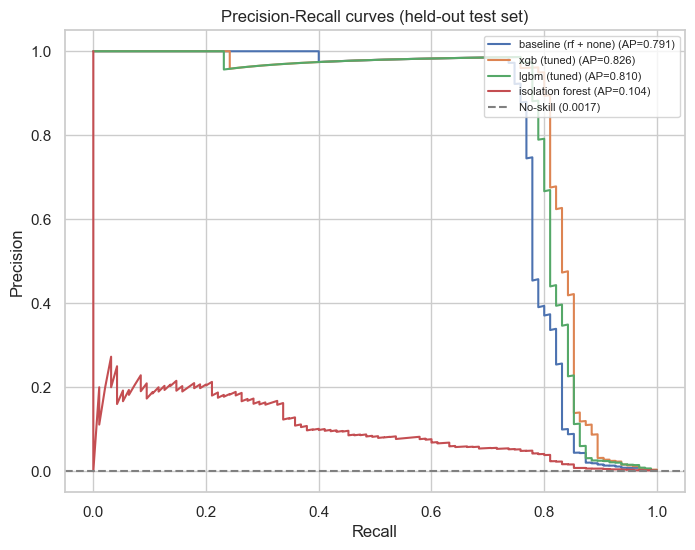

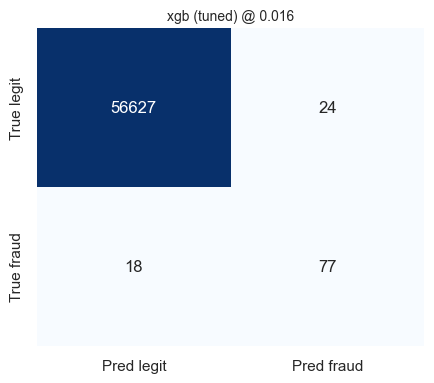

In [11]:
ax = plot_pr_curves(y_test, test_scores)
ax.set_title("Precision-Recall curves (held-out test set)")
plt.show()

plot_confusion_matrices(
    y_test, {f"{winner_label} @ {CHOSEN_THRESHOLD:.3f}": winner_scores},
    threshold=CHOSEN_THRESHOLD)
plt.show()

10. Business view on the test set

Same frozen thresholds applied to the test predictions. The cost comparison shows what the model saves compared with flagging nothing.

In [12]:
report = pd.DataFrame({
    "default 0.5": compute_metrics(y_test, winner_scores, 0.5),
    f"cost-based {threshold_info['cost_based']:.3f}": compute_metrics(
        y_test, winner_scores, threshold_info["cost_based"]),
    f"recall>=90% {threshold_info['recall_target']:.3f}": compute_metrics(
        y_test, winner_scores, threshold_info["recall_target"]),
}).T
display(report.round(3))

cost = cost_at_threshold(y_test, winner_scores, CHOSEN_THRESHOLD,
                         MISSED_COST, ALARM_COST)
print({k: round(v, 1) for k, v in cost.items()})

,precision,recall,f1,pr_auc,roc_auc
default 0.5,0.960,0.758,0.847,0.826,0.983
cost-based 0.016,0.762,0.811,0.786,0.826,0.983
recall>=90% 0.000,0.108,0.884,0.193,0.826,0.983


{'cost': 2206.9, 'cost_no_model': 11014.2, 'cost_flag_all': 283255.0}


11. SHAP: what drives the model?

The explainer is built on the final model. The global plots use a training-data sample (all frauds + 3,000 legit rows), so the test set plays no role. Importance here reflects fraud-vs-legit separation. V1-V28 are anonymized PCA components, so say "the model relies on component V14", not "V14 means X".

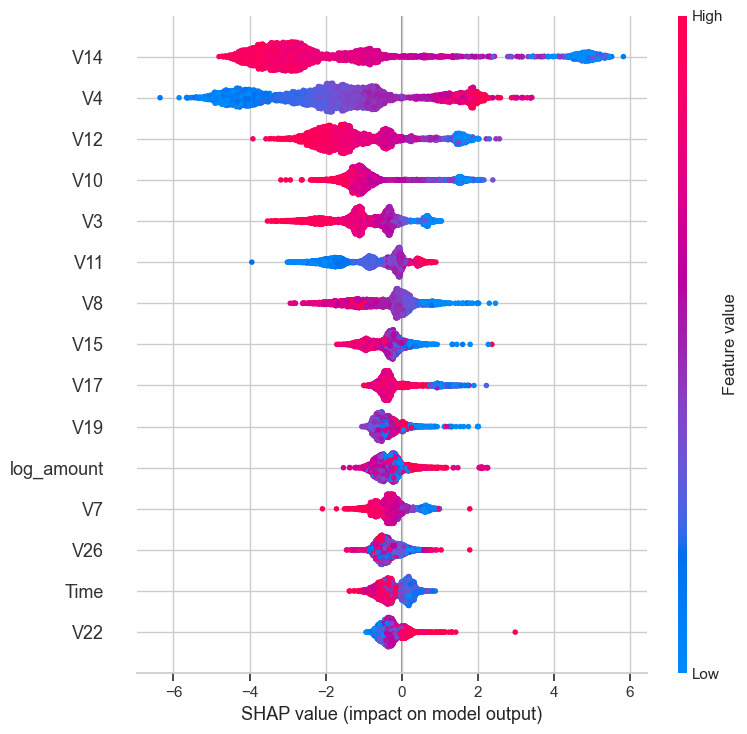

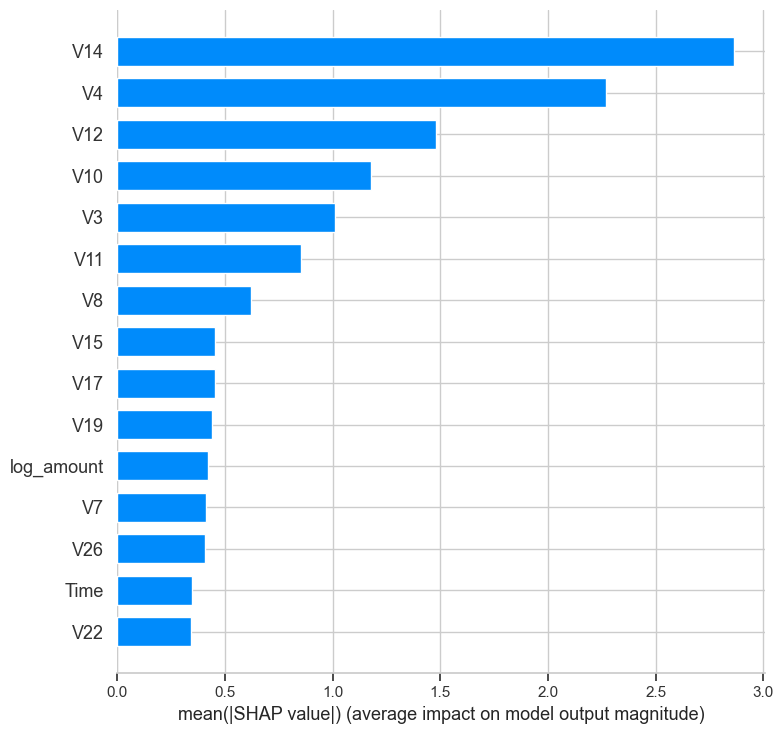

,mean_abs_shap
V14,2.865
V4,2.268
V12,1.481
V10,1.177
V3,1.010
V11,0.850
V8,0.620
V15,0.454
V17,0.453
V19,0.441


In [13]:
final = fitted[winner]
explainer = build_explainer(final["model"])
X_train_t = final["pre"].transform(X_train)
X_sample = sample_for_shap(X_train_t, y_train, n_legit=3000)
importance = plot_global_importance(explainer, X_sample)
display(importance.head(10).round(3).to_frame("mean_abs_shap"))

12. Why was this transaction flagged (or missed)?

Cases are drawn from the test set after evaluation, with seed 42. This is explanation only and changes no decision. A waterfall starts at the base value and each bar adds or subtracts log-odds.

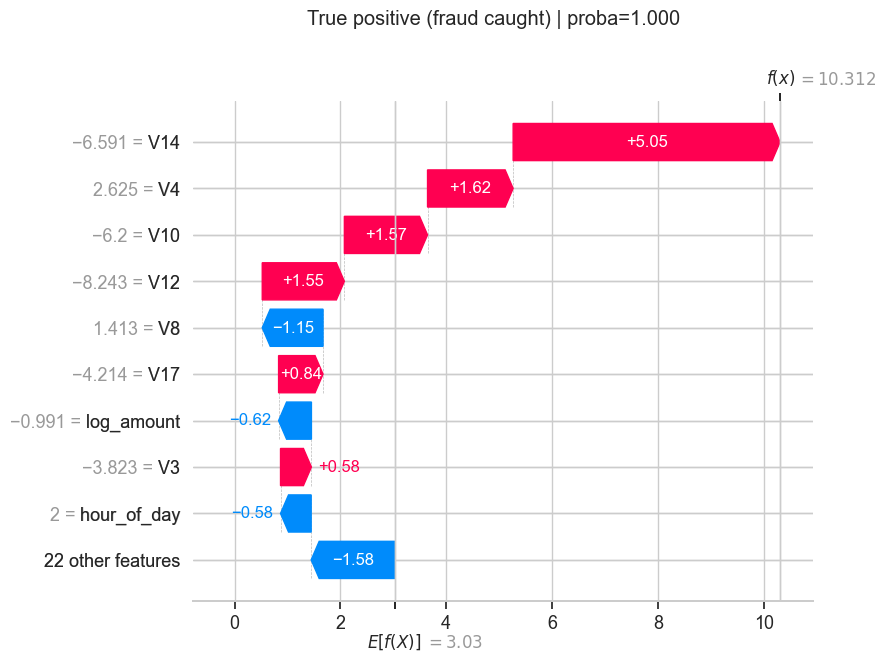

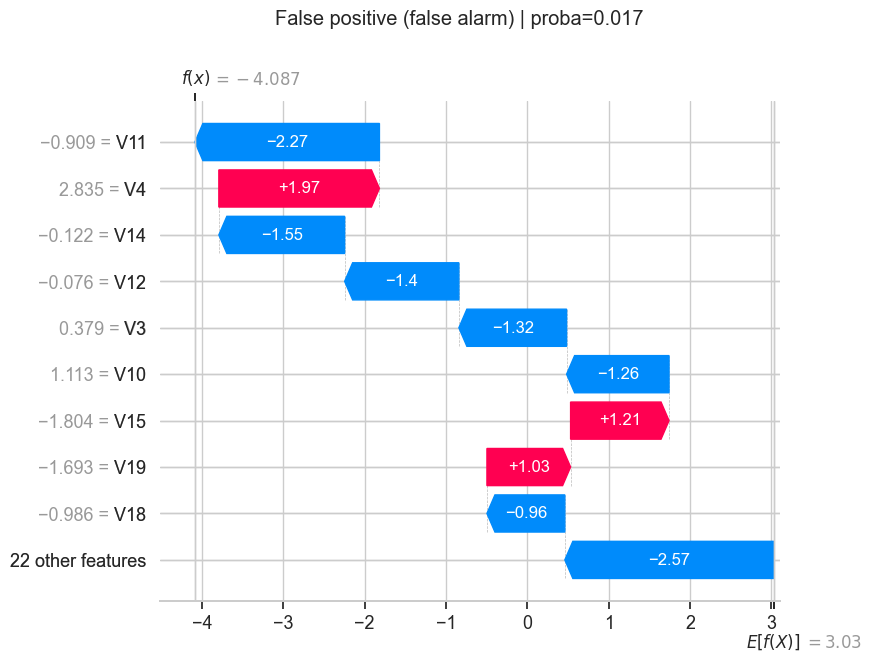

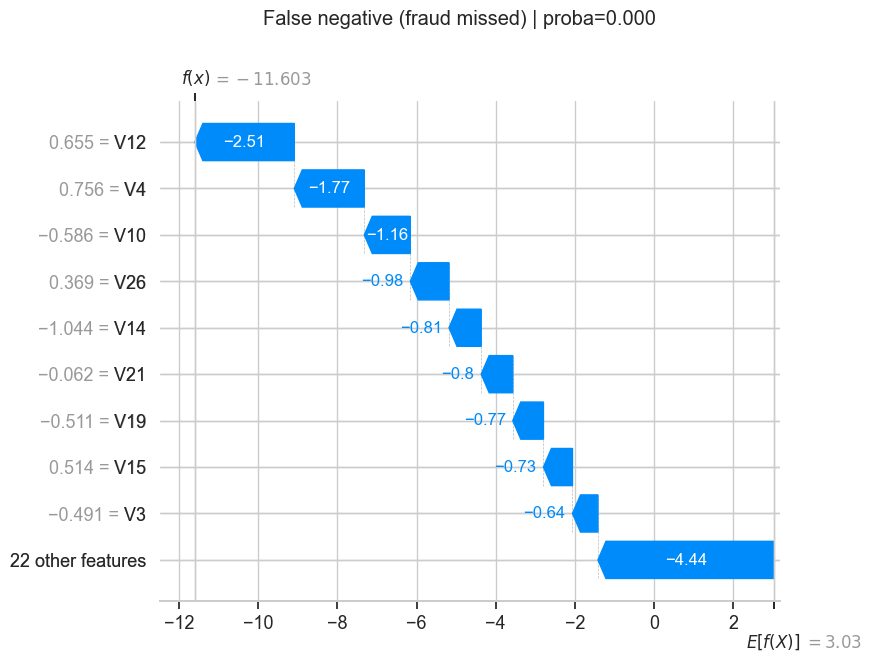

[{'feature': 'V14', 'value': -0.292841860600363, 'shap_value': -2.4843363761901855, 'effect': 'decreases fraud risk'}, {'feature': 'V11', 'value': -1.25272793883718, 'shap_value': -1.9411498308181763, 'effect': 'decreases fraud risk'}, {'feature': 'V12', 'value': 0.465078770741453, 'shap_value': -1.7958011627197266, 'effect': 'decreases fraud risk'}, {'feature': 'V10', 'value': -0.273053702248503, 'shap_value': -1.2104518413543701, 'effect': 'decreases fraud risk'}, {'feature': 'V4', 'value': 0.647465021810117, 'shap_value': -1.126470685005188, 'effect': 'decreases fraud risk'}]


In [14]:
X_test_t = final["pre"].transform(X_test)
pred = winner_scores >= CHOSEN_THRESHOLD
truth = y_test.to_numpy() == 1
rng = np.random.default_rng(RANDOM_STATE)

cases = {
    "True positive (fraud caught)": np.flatnonzero(pred & truth),
    "False positive (false alarm)": np.flatnonzero(pred & ~truth),
    "False negative (fraud missed)": np.flatnonzero(~pred & truth),
}
for title, idx in cases.items():
    if len(idx) == 0:
        print(f"{title}: none at this threshold")
        continue
    pick = int(rng.choice(idx))
    plot_waterfall(explainer, X_test_t.iloc[[pick]],
                   f"{title} | proba={winner_scores[pick]:.3f}")

print(explain_transaction(final["model"], X_test_t.iloc[[0]],
                          explainer=explainer))

13. Save artifacts and prove they reload

The saved preprocessor accepts raw columns, which is what the API will receive

In [15]:
save_artifacts(
    model=final["model"],
    preprocessor=final["pre"],
    threshold_info=threshold_info,
    explainer=explainer,
    model_name=winner,
    metrics=compute_metrics(y_test, winner_scores, CHOSEN_THRESHOLD),
    params=records[winner]["best_params"],
)

artifacts = load_artifacts()
raw_row = X_test.iloc[[0]]
result = score_and_explain(artifacts, raw_row)
print(result)
assert np.isclose(result["fraud_probability"], winner_scores[0])
print(sorted(p.name for p in MODELS_DIR.iterdir() if p.is_file()))

{'fraud_probability': 1.5615380561939673e-06, 'is_fraud': False, 'threshold': 0.015768153592944145, 'top_factors': [{'feature': 'V14', 'value': -0.292841860600363, 'shap_value': -2.4843363761901855, 'effect': 'decreases fraud risk'}, {'feature': 'V11', 'value': -1.25272793883718, 'shap_value': -1.9411498308181763, 'effect': 'decreases fraud risk'}, {'feature': 'V12', 'value': 0.465078770741453, 'shap_value': -1.7958011627197266, 'effect': 'decreases fraud risk'}, {'feature': 'V10', 'value': -0.273053702248503, 'shap_value': -1.2104518413543701, 'effect': 'decreases fraud risk'}, {'feature': 'V4', 'value': 0.647465021810117, 'shap_value': -1.126470685005188, 'effect': 'decreases fraud risk'}]}
['.gitkeep', 'best_baseline.joblib', 'final_model.joblib', 'metadata.json', 'preprocessor.joblib', 'shap_explainer.joblib', 'threshold.joblib', 'tuning_lgbm.json', 'tuning_xgb.json']
